In [ ]:
#eFLh5rBnGeuFTJyiG9WF9VIBANGqnkEO###

In [ ]:
# Установка необходимых библиотек
!pip install pandas scikit-learn requests

import pandas as pd
import numpy as np
import requests
import json
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


In [ ]:
# Загрузка данных
def load_and_explore_data(file_path):
    try:
        df = pd.read_csv(file_path)
        print(f"✅ Данные успешно загружены")
        print(f"Размер данных: {df.shape}")
        print(f"Колонки: {list(df.columns)}")

        # Основная информация о данных
        print("\n📊 Основная информация:")
        print(df.info())

        # Пропущенные значения
        print("\n🔍 Пропущенные значения:")
        missing_data = df.isnull().sum()
        print(missing_data[missing_data > 0])

        # Статистика по зарплатам
        print("\n💰 Статистика по зарплатам (USD):")
        if 'salary_in_usd' in df.columns:
            print(df['salary_in_usd'].describe())

        return df

    except Exception as e:
        print(f"❌ Ошибка загрузки данных: {e}")
        return None

# Замените путь к вашему файлу
file_path = "cleaned_data_jobs_salaries_2023_2024.csv"
df = load_and_explore_data(file_path)

✅ Данные успешно загружены
Размер данных: (4497, 40)
Колонки: ['spark', 'hourly', 'location', 'work_year', 'remote_ratio', 'company_txt', 'python_yn', 'job title', 'r_yn', 'max_salary', 'aws', 'excel', 'company name', 'company_size', 'job_state', 'type of ownership', 'experience_level', 'salary_currency', 'min_salary', 'same_state', 'salary estimate', 'industry', 'headquarters', 'company_location', 'salary', 'employer_provided', 'source', 'age', 'salary_in_usd', 'sector', 'job description', 'avg_salary', 'job_title', 'rating', 'revenue', 'employment_type', 'competitors', 'size', 'employee_residence', 'founded']

📊 Основная информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4497 entries, 0 to 4496
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   spark               742 non-null    float64
 1   hourly              742 non-null    float64
 2   location            742 non-null    object 
 3   

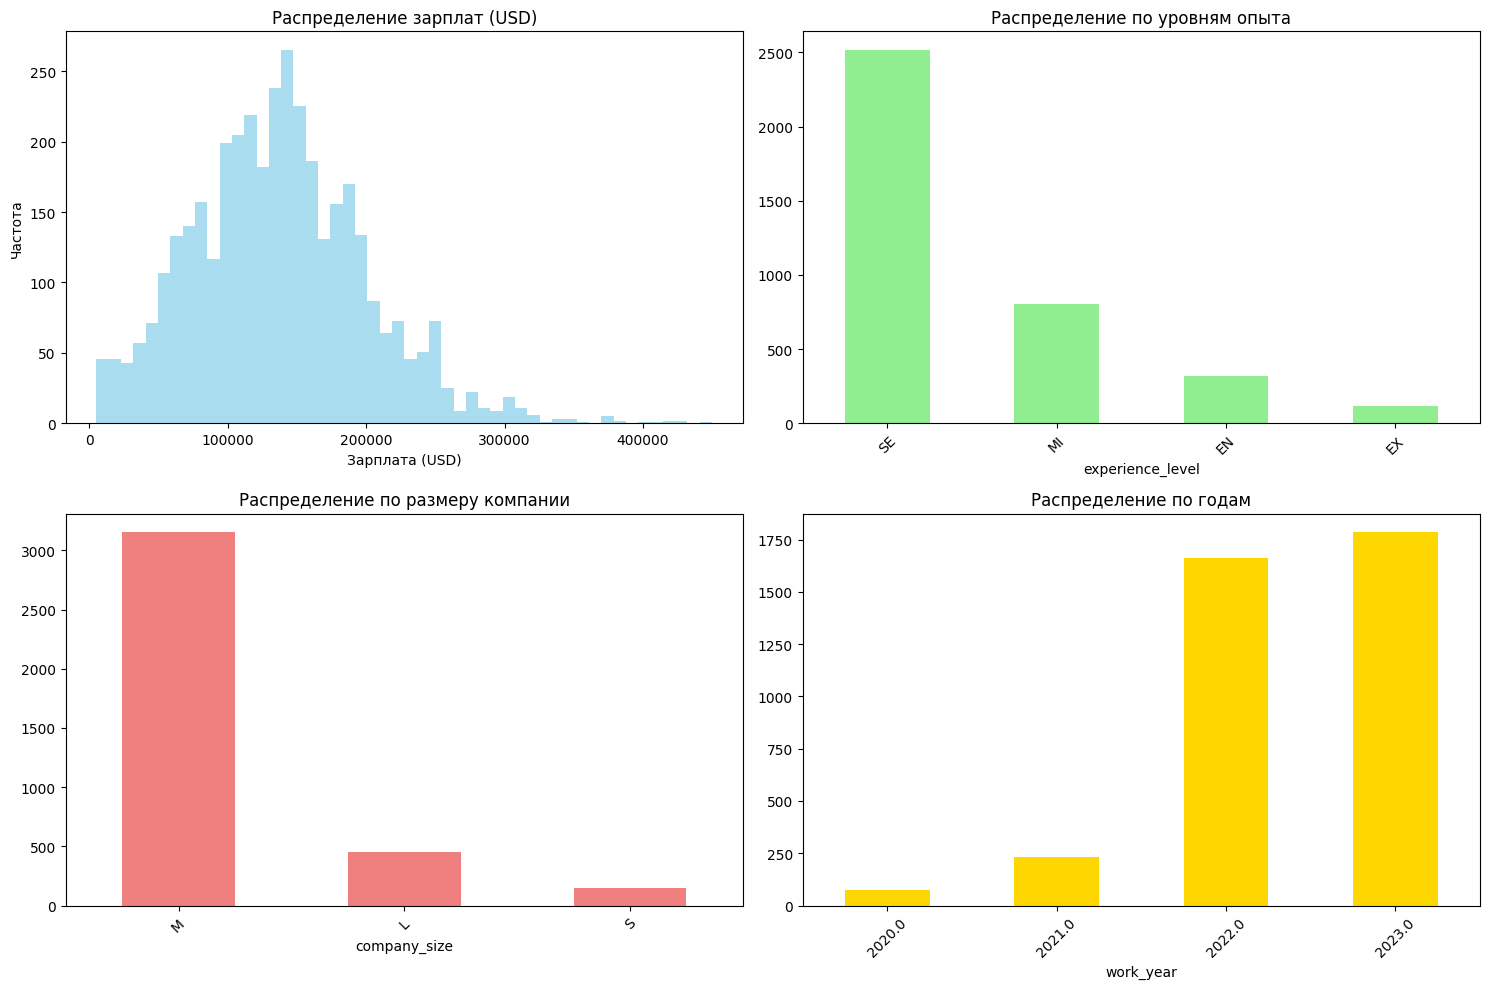

In [ ]:
# Визуализация распределения данных
def visualize_data(df):
    if df is None:
        print("❌ Данные не загружены")
        return

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Распределение зарплат
    if 'salary_in_usd' in df.columns:
        axes[0,0].hist(df['salary_in_usd'].dropna(), bins=50, alpha=0.7, color='skyblue')
        axes[0,0].set_title('Распределение зарплат (USD)')
        axes[0,0].set_xlabel('Зарплата (USD)')
        axes[0,0].set_ylabel('Частота')

    # Распределение по уровням опыта
    if 'experience_level' in df.columns:
        df['experience_level'].value_counts().plot(kind='bar', ax=axes[0,1], color='lightgreen')
        axes[0,1].set_title('Распределение по уровням опыта')
        axes[0,1].tick_params(axis='x', rotation=45)

    # Распределение по размеру компании
    if 'company_size' in df.columns:
        df['company_size'].value_counts().plot(kind='bar', ax=axes[1,0], color='lightcoral')
        axes[1,0].set_title('Распределение по размеру компании')
        axes[1,0].tick_params(axis='x', rotation=45)

    # Распределение по году
    if 'work_year' in df.columns:
        df['work_year'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='gold')
        axes[1,1].set_title('Распределение по годам')
        axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

visualize_data(df)

In [ ]:
# Предобработка данных для ML модели
def preprocess_data(df):
    print("🔄 Начинаем предобработку данных...")

    # Выбираем релевантные признаки
    features = ['work_year', 'remote_ratio', 'company_size', 'experience_level', 'salary_in_usd']

    # Проверяем наличие колонок
    available_features = [col for col in features if col in df.columns]
    print(f"Доступные признаки: {available_features}")

    # Создаем копию данных для обработки
    df_processed = df[available_features].copy()

    # Удаляем строки с пропущенными значениями
    initial_size = len(df_processed)
    df_processed = df_processed.dropna()
    final_size = len(df_processed)

    print(f"Удалено строк с пропусками: {initial_size - final_size}")
    print(f"Осталось строк: {final_size}")

    # Кодируем категориальные переменные
    label_encoders = {}
    categorical_columns = ['company_size', 'experience_level']

    for col in categorical_columns:
        if col in df_processed.columns:
            print(f"Кодируем колонку: {col}")
            print(f"Уникальные значения до кодирования: {df_processed[col].unique()}")

            label_encoders[col] = LabelEncoder()
            df_processed[col] = label_encoders[col].fit_transform(df_processed[col])

            print(f"Уникальные значения после кодирования: {df_processed[col].unique()}")

    # Сохраняем названия колонок признаков
    feature_columns = [col for col in df_processed.columns if col != 'salary_in_usd']

    # Разделяем на признаки и целевую переменную
    X = df_processed[feature_columns]
    y = df_processed['salary_in_usd']

    print(f"Признаки: {feature_columns}")
    print(f"Размер X: {X.shape}, Размер y: {y.shape}")

    return X, y, label_encoders, feature_columns

X, y, label_encoders, feature_columns = preprocess_data(df)

🔄 Начинаем предобработку данных...
Доступные признаки: ['work_year', 'remote_ratio', 'company_size', 'experience_level', 'salary_in_usd']
Удалено строк с пропусками: 742
Осталось строк: 3755
Кодируем колонку: company_size
Уникальные значения до кодирования: ['L' 'S' 'M']
Уникальные значения после кодирования: [0 2 1]
Кодируем колонку: experience_level
Уникальные значения до кодирования: ['SE' 'MI' 'EN' 'EX']
Уникальные значения после кодирования: [3 2 0 1]
Признаки: ['work_year', 'remote_ratio', 'company_size', 'experience_level']
Размер X: (3755, 4), Размер y: (3755,)


In [ ]:
# Обучение модели Random Forest
def train_ml_model(X, y):
    print("🤖 Начинаем обучение модели...")

    # Разделяем на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(f"Обучающая выборка: {X_train.shape}")
    print(f"Тестовая выборка: {X_test.shape}")

    # Обучаем модель
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Оцениваем качество модели
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"✅ Модель обучена!")
    print(f"R² на обучающей выборке: {train_score:.3f}")
    print(f"R² на тестовой выборке: {test_score:.3f}")

    # Важность признаков
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n🔍 Важность признаков:")
    print(feature_importance)

    return model, X_train, X_test, y_train, y_test

model, X_train, X_test, y_train, y_test = train_ml_model(X, y)

🤖 Начинаем обучение модели...
Обучающая выборка: (3004, 4)
Тестовая выборка: (751, 4)
✅ Модель обучена!
R² на обучающей выборке: 0.294
R² на тестовой выборке: 0.193

🔍 Важность признаков:
            feature  importance
3  experience_level    0.642818
1      remote_ratio    0.130345
0         work_year    0.124109
2      company_size    0.102728


In [ ]:
# Функция для предсказания зарплаты с помощью ML модели
def predict_salary_ml(model, label_encoders, feature_columns, input_params):
    """
    Предсказание зарплаты с помощью ML модели

    Параметры:
    - work_year: год работы (например, 2024)
    - remote_ratio: процент удаленной работы (0-100)
    - company_size: размер компании ('S', 'M', 'L')
    - experience_level: уровень опыта ('MI', 'SE', 'EX', 'EN')
    """

    try:
        # Подготавливаем входные данные
        input_data = {
            'work_year': input_params.get('work_year', 2024),
            'remote_ratio': input_params.get('remote_ratio', 50),
            'company_size': input_params.get('company_size', 'M'),
            'experience_level': input_params.get('experience_level', 'SE')
        }

        print(f"Входные параметры: {input_data}")

        # Создаем DataFrame с правильным порядком колонок
        input_df = pd.DataFrame([input_data])

        # Кодируем категориальные переменные
        for col in ['company_size', 'experience_level']:
            if col in label_encoders:
                try:
                    input_df[col] = label_encoders[col].transform([input_data[col]])[0]
                except ValueError as e:
                    print(f"❌ Ошибка кодирования {col}: {e}")
                    available_values = label_encoders[col].classes_
                    print(f"Доступные значения: {available_values}")
                    return None

        # Предсказание
        prediction = model.predict(input_df[feature_columns])

        result = round(prediction[0], 2)
        print(f"💰 Предсказанная зарплата: ${result:,.2f} USD")

        return result

    except Exception as e:
        print(f"❌ Ошибка предсказания: {e}")
        return None

# Тестируем ML модель
test_params = {
    'work_year': 2024,
    'remote_ratio': 50,
    'company_size': 'M',
    'experience_level': 'SE'
}

ml_prediction = predict_salary_ml(model, label_encoders, feature_columns, test_params)

Входные параметры: {'work_year': 2024, 'remote_ratio': 50, 'company_size': 'M', 'experience_level': 'SE'}
💰 Предсказанная зарплата: $72,222.99 USD


In [ ]:
# Функция для работы с Mistral API
class MistralSalaryAnalyzer:
    def __init__(self, api_key):
        self.api_key = api_key
        self.url = "https://api.mistral.ai/v1/chat/completions"

    def get_salary_analysis(self, job_info, ml_prediction=None):
        """Получение анализа зарплаты от Mistral"""

        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json"
        }

        ml_info = f"Предсказание ML модели: ${ml_prediction:,.2f} USD\n" if ml_prediction else ""

        prompt = f"""
        Ты - эксперт по анализу зарплат в сфере data science.
        Проанализируй рыночную зарплату для следующей позиции:

        Должность: {job_info['job_title']}
        Уровень опыта: {job_info.get('experience_level', 'не указан')}
        Размер компании: {job_info.get('company_size', 'не указан')}
        Удаленная работа: {job_info.get('remote_ratio', 'не указано')}%
        Локация: {job_info.get('location', 'не указана')}
        {ml_info}

        Предоставь анализ в следующем формате:

        📊 ПРЕДСКАЗАНИЕ ЗАРПЛАТЫ

        💰 Диапазон зарплаты: $X,XXX - $X,XXX USD
        🎯 Уверенность: высокая/средняя/низкая

        🔍 Ключевые факторы:
        • Фактор 1
        • Фактор 2
        • Фактор 3

        📈 Анализ рынка:
        Краткий анализ текущей рыночной ситуации

        💡 Рекомендации:
        • Рекомендация 1
        • Рекомендация 2

        Ответ должен быть структурированным и информативным.
        """

        payload = {
            "model": "mistral-medium",
            "messages": [
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            "temperature": 0.3,
            "max_tokens": 800
        }

        try:
            print("🔄 Запрос к Mistral API...")
            response = requests.post(self.url, headers=headers, json=payload, timeout=30)
            response.raise_for_status()

            result = response.json()
            analysis = result["choices"][0]["message"]["content"]

            print("✅ Ответ от Mistral получен!")
            return analysis

        except requests.exceptions.RequestException as e:
            return f"❌ Ошибка API запроса: {e}"
        except Exception as e:
            return f"❌ Неожиданная ошибка: {e}"

# Тестируем Mistral API (замените на ваш API ключ)
MISTRAL_API_KEY = ""  # ⚠️ ЗАМЕНИТЕ НА ВАШ КЛЮЧ

if MISTRAL_API_KEY != "your_mistral_api_key_here":
    analyzer = MistralSalaryAnalyzer(MISTRAL_API_KEY)

    job_info = {
        'job_title': 'Data Scientist',
        'experience_level': 'SE',
        'company_size': 'M',
        'remote_ratio': 50,
        'location': 'United States'
    }

    mistral_analysis = analyzer.get_salary_analysis(job_info, ml_prediction)
    print("\n" + "="*50)
    print("АНАЛИЗ ОТ MISTRAL AI:")
    print("="*50)
    print(mistral_analysis)
else:
    print("⚠️ Установите ваш Mistral API ключ для тестирования")

🔄 Запрос к Mistral API...
✅ Ответ от Mistral получен!

АНАЛИЗ ОТ MISTRAL AI:
```
📊 **ПРЕДСКАЗАНИЕ ЗАРПЛАТЫ**

💰 **Диапазон зарплаты:** **$68,000 – $85,000 USD** (годовая брутто)
🎯 **Уверенность:** **Средняя** (с возможностью корректировки в зависимости от специфики компании и навыков кандидата)

---

### **🔍 Ключевые факторы:**
• **Уровень опыта (SE – Senior Engineer/Scientist):**
  - SE-уровень в Data Science обычно подразумевает **3–6 лет опыта** с фокусом на производственные ML-системы, менторинг младших коллег и участие в архитектурных решениях. Зарплаты для этого уровня в США варьируются от **$80K до $130K**, но **50% удаленности** и **средний размер компании (M)** могут снижать верхнюю планку.

• **Размер компании (M – Mid-size, 100–1000 сотрудников):**
  - Компании этого сегмента часто предлагают **ниже зарплат, чем FAANG/Big Tech**, но выше, чем стартапы. Средний диапазон для DS в M-компаниях: **$70K–$100K**. Бонусы и акции (если есть) могут компенсировать разницу.

• **Локация

In [ ]:
# Комплексная функция предсказания зарплаты
class SalaryPredictor:
    def __init__(self, ml_model, label_encoders, feature_columns, mistral_api_key=None):
        self.ml_model = ml_model
        self.label_encoders = label_encoders
        self.feature_columns = feature_columns
        self.mistral_analyzer = MistralSalaryAnalyzer(mistral_api_key) if mistral_api_key else None

    def predict_salary(self, job_params):
        """Комплексное предсказание зарплаты"""

        print("🎯 Начинаем анализ зарплаты...")
        print(f"Должность: {job_params['job_title']}")

        # ML предсказание
        ml_input = {
            'work_year': job_params.get('work_year', 2024),
            'remote_ratio': job_params.get('remote_ratio', 50),
            'company_size': job_params.get('company_size', 'M'),
            'experience_level': job_params.get('experience_level', 'SE')
        }

        ml_prediction = predict_salary_ml(
            self.ml_model, self.label_encoders, self.feature_columns, ml_input
        )

        result = {
            'ml_prediction': ml_prediction,
            'input_parameters': job_params
        }

        # Анализ от Mistral (если доступен API ключ)
        if self.mistral_analyzer and ml_prediction:
            print("🔄 Получаем анализ от Mistral AI...")
            result['mistral_analysis'] = self.mistral_analyzer.get_salary_analysis(
                job_params, ml_prediction
            )

        return result

# Инициализация и тестирование комплексного предсказателя
predictor = SalaryPredictor(model, label_encoders, feature_columns, MISTRAL_API_KEY)

# Тестовый запрос
test_job = {
    'job_title': 'Senior Data Scientist',
    'experience_level': 'SE',
    'company_size': 'L',
    'remote_ratio': 75,
    'location': 'United States',
    'work_year': 2024
}

final_result = predictor.predict_salary(test_job)

print("\n" + "="*60)
print("ФИНАЛЬНЫЙ РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ")
print("="*60)

print(f"\n📋 Входные параметры:")
for key, value in final_result['input_parameters'].items():
    print(f"  {key}: {value}")

print(f"\n🤖 ML предсказание: ${final_result['ml_prediction']:,.2f} USD")

if 'mistral_analysis' in final_result:
    print(f"\n🧠 Анализ Mistral AI:")
    print(final_result['mistral_analysis'])

🎯 Начинаем анализ зарплаты...
Должность: Senior Data Scientist
Входные параметры: {'work_year': 2024, 'remote_ratio': 75, 'company_size': 'L', 'experience_level': 'SE'}
💰 Предсказанная зарплата: $86,246.82 USD
🔄 Получаем анализ от Mistral AI...
🔄 Запрос к Mistral API...
✅ Ответ от Mistral получен!

ФИНАЛЬНЫЙ РЕЗУЛЬТАТ ПРЕДСКАЗАНИЯ

📋 Входные параметры:
  job_title: Senior Data Scientist
  experience_level: SE
  company_size: L
  remote_ratio: 75
  location: United States
  work_year: 2024

🤖 ML предсказание: $86,246.82 USD

🧠 Анализ Mistral AI:
```
📊 **ПРЕДСКАЗАНИЕ ЗАРПЛАТЫ (Senior Data Scientist, USA, 75% удалёнка)**

💰 **Диапазон зарплаты:** **$120,000 – $160,000 USD** (годовая брутто)
🎯 **Уверенность:** **Средняя** (с тенденцией к высокой при уточнении деталей)

---
### **🔍 Ключевые факторы, влияющие на зарплату:**
• **Уровень опыта (SE – Senior Engineer/Scientist):**
  - Senior-специалисты в США с 5+ годами опыта обычно получают **$130K–$170K** (по данным [Levels.fyi](https://www.l

In [ ]:
# Демонстрация работы с разными сценариями
def demo_different_scenarios(predictor):
    """Демонстрация предсказаний для разных сценариев"""

    scenarios = [
        {
            'name': 'Младший специалист в стартапе',
            'params': {
                'job_title': 'Junior Data Analyst',
                'experience_level': 'MI',
                'company_size': 'S',
                'remote_ratio': 20,
                'location': 'United States'
            }
        },
        {
            'name': 'Средний специалист в средней компании',
            'params': {
                'job_title': 'Data Scientist',
                'experience_level': 'SE',
                'company_size': 'M',
                'remote_ratio': 50,
                'location': 'United States'
            }
        },
        {
            'name': 'Старший специалист в крупной компании',
            'params': {
                'job_title': 'Senior Machine Learning Engineer',
                'experience_level': 'EX',
                'company_size': 'L',
                'remote_ratio': 100,
                'location': 'United States'
            }
        }
    ]

    for scenario in scenarios:
        print(f"\n{'='*50}")
        print(f"СЦЕНАРИЙ: {scenario['name']}")
        print(f"{'='*50}")

        result = predictor.predict_salary(scenario['params'])

        if result['ml_prediction']:
            print(f"💰 Предсказанная зарплата: ${result['ml_prediction']:,.2f} USD")

        print("-" * 50)

# Запуск демонстрации
print("🚀 ЗАПУСК ДЕМОНСТРАЦИИ РАЗНЫХ СЦЕНАРИЕВ")
demo_different_scenarios(predictor)

🚀 ЗАПУСК ДЕМОНСТРАЦИИ РАЗНЫХ СЦЕНАРИЕВ

СЦЕНАРИЙ: Младший специалист в стартапе
🎯 Начинаем анализ зарплаты...
Должность: Junior Data Analyst
Входные параметры: {'work_year': 2024, 'remote_ratio': 20, 'company_size': 'S', 'experience_level': 'MI'}
💰 Предсказанная зарплата: $122,234.35 USD
🔄 Получаем анализ от Mistral AI...
🔄 Запрос к Mistral API...
✅ Ответ от Mistral получен!
💰 Предсказанная зарплата: $122,234.35 USD
--------------------------------------------------

СЦЕНАРИЙ: Средний специалист в средней компании
🎯 Начинаем анализ зарплаты...
Должность: Data Scientist
Входные параметры: {'work_year': 2024, 'remote_ratio': 50, 'company_size': 'M', 'experience_level': 'SE'}
💰 Предсказанная зарплата: $72,222.99 USD
🔄 Получаем анализ от Mistral AI...
🔄 Запрос к Mistral API...
✅ Ответ от Mistral получен!
💰 Предсказанная зарплата: $72,222.99 USD
--------------------------------------------------

СЦЕНАРИЙ: Старший специалист в крупной компании
🎯 Начинаем анализ зарплаты...
Должность: Senior